In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
penguins = sns.load_dataset('penguins')

In [3]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Parameters for RFC are X and y.
X is the feature matrix (the input), y is the outcome (usually a column vector).
In this case, y could be the species column and X all of the other variable columns (except the species column!)

In [4]:
penguins = penguins.dropna()
everything_else = penguins.drop(columns=['species', 'island', 'sex'])

In [5]:
everything_else

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0
...,...,...,...,...
338,47.2,13.7,214.0,4925.0
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


In [6]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


Note: 'fit' here would be easier to explain if fitting numeric data to a distribution had already been discussed.

In [7]:
# OHE = OneHotEncoder(sparse_output=False).fit_transform(everything_else)

in the Lab lesson, they filter out island and sex variables. we could do the same, to keep things simple. but want to bring them back later for discussion. or at least the island, since sex would be relatively easily encoded as well. Brings good opportunities to discuss some of the complexities that need to be considered in practice, with the help of your local statistician.

Next steps: follow the Lab DL lesson, i.e. use pandas to do the OHE. Consider removing only island at this stage and not sex as well.

In [8]:
target = pd.get_dummies(penguins['species']) # a dataframe with species as column headings, True/False values according to teh species of each row.

In [9]:
target

,Adelie,Chinstrap,Gentoo
0,True,False,False
1,True,False,False
2,True,False,False
4,True,False,False
5,True,False,False
...,...,...,...
338,False,False,True
340,False,False,True
341,False,False,True
342,False,False,True


In [10]:
X_train, X_test, y_train, y_test = train_test_split(everything_else, target, test_size=0.2, random_state=0, shuffle=True, stratify=target)

In [11]:
X_train

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
86,36.3,19.5,190.0,3800.0
43,44.1,19.7,196.0,4400.0
67,41.1,19.1,188.0,4100.0
156,52.7,19.8,197.0,3725.0
80,34.6,17.2,189.0,3200.0
...,...,...,...,...
243,46.3,15.8,215.0,5050.0
213,46.8,16.5,189.0,3650.0
109,43.2,19.0,197.0,4775.0
342,45.2,14.8,212.0,5200.0


In [12]:
y_train

,Adelie,Chinstrap,Gentoo
86,True,False,False
43,True,False,False
67,True,False,False
156,False,True,False
80,True,False,False
...,...,...,...
243,False,False,True
213,False,True,False
109,True,False,False
342,False,False,True


Create a random forest object and train it on the data we just split out.

In [13]:
clf = RandomForestClassifier()

In [14]:
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Now use the trained model to predict the classes of the rows in the test data.

In [15]:
predicted_classes = clf.predict(X_test)
predicted_classes = pd.DataFrame(predicted_classes, columns=y_test.columns)
predicted_classes = predicted_classes.idxmax(axis="columns")
true_classes = y_test.idxmax(axis="columns")

In [16]:
# check if each prediction is one class (one versus rest)

And compare these results to the true values in `y_test`.

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

In [18]:
# trying to make the equivalent of https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
# disp = ConfusionMatrixDisplay.from_estimator(
#         RFC,
#         X_test,
#         true_classes,
#         display_labels=target.columns,
#         cmap=plt.cm.Blues,
#     )
# print(disp.confusion_matrix)
# plt.show()
from sklearn.metrics import confusion_matrix
matrix = confusion_matrix(true_classes, predicted_classes)
print(matrix)

[[27  2  0]
 [ 1 13  0]
 [ 0  0 24]]


In [19]:
# Convert to a pandas dataframe
confusion_df = pd.DataFrame(matrix, index=y_test.columns.values, columns=y_test.columns.values)
confusion_df.index.name = 'True Label'
confusion_df.columns.name = 'Predicted Label'
confusion_df

Predicted Label,Adelie,Chinstrap,Gentoo
True Label,,,
Adelie,27,2,0
Chinstrap,1,13,0
Gentoo,0,0,24


<Axes: xlabel='Predicted Label', ylabel='True Label'>

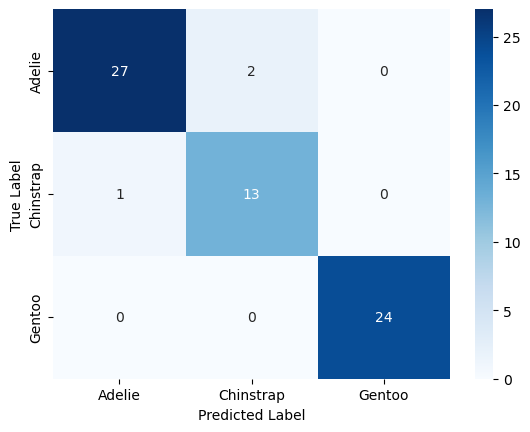

In [20]:
sns.heatmap(confusion_df, annot=True, cmap='Blues')

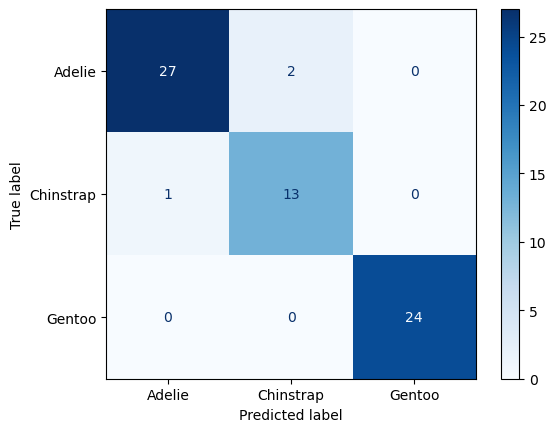

In [21]:
# this uses sklearn instead of seaborn for plotting
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=target.columns)
disp.plot(cmap=plt.cm.Blues);

**The numbers do not match what's in the DL lesson. Double check?**

* need to check if scikit RFC predicits exactly one class
* probably should do some stats on the data above

* think about which libraries to use for what (uschille: I favor being parsimonious to increase cohesion and avoid context switching -> reduce cognitive load)
  - we might even provide the dataset in a different format to avoid seaborn? (if that's the only thing it is neccessary for)
* Claudia: derived model that handles the input (to handle all the conversions -> "wrapper")

* now here we could at accuracy, precision, recall, etc. (for case of multi-label classification as opposed to true/false)

In [22]:
# TP, FP, FN, TP -> this will need some explanation in the context of multi-class 
true_positives = np.diag(matrix) # true positives per class
false_positives = np.sum(matrix, axis=0) - true_positives # column sum is the number of predictions for each class, subtracting true positives gives false positives ("excess positives")
false_negatives = np.sum(matrix, axis=1) - true_positives # row sum is the number of true occurences for each class, subtracting true positives gives false negatives ("missing positives")
true_negatives = np.sum(matrix) - (true_positives + false_positives + false_negatives)

In [23]:
false_positives, false_negatives, true_negatives

(array([1, 2, 0]), array([2, 1, 0]), array([37, 51, 43]))

In [24]:
# scikit may have a way to get these

In [25]:
accuracy = (true_positives + true_negatives)/np.sum(matrix) # correct predicitions among all predictions -> check for multi-class
precision = true_positives/(true_positives + false_positives) # rate of true positives among positivies
recall = true_positives/(true_positives + false_negatives) # rate of true positivies among actual occurences
accuracy, precision, recall

# sensitivity
# specificity
# positive predictive value
# negative predictive value

(array([0.95522388, 0.95522388, 1.        ]),
 array([0.96428571, 0.86666667, 1.        ]),
 array([0.93103448, 0.92857143, 1.        ]))

### Try the whole thing without one-hot

In [7]:
df = sns.load_dataset('penguins') # look at your data!
df = df.dropna() # think about what to do about missing values (topic for data prep lesson), refer to guidance in DC Ecology etc lessons
features = df.drop(columns=["species", "island", "sex"]) # discuss why to drop the columns, what alternatives there could be (come back to that second point later so as not to distract at this early stage?)
# we could also do the above, in two steps: drop island and sex in a pre-processing step, whereas species is dropped because it will become the labels.
labels = df["species"] # you will have two objects to handle, be careful to treat them equally downstream

In [11]:
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=0, shuffle=True, stratify=labels)
# will this be the first time we do a test/train split?
# if yes, focus here on implementation: what do we do in scikit learn to make this happen?
# why do we choose these values for the arguments? what would change if we used different values?
# an exercise, where learners play around with these and see what changes downstream. Impractical to go through every parameter that could be changed, so we could point learners towards reference documentation for the exhaustive list.


In [18]:
clf = RandomForestClassifier() # what is the random forest doing? what other methods are available for classification?
clf.fit(X_train, y_train); # what does .fit produce? how does it change what the object contains?
# the in-place action of .fit can catch newcomers out.
# can we inspect/explore it a bit? depends a little on how much we have been able to explain what the random forest does/how it works, and what options we have for representing that from the attributes etc of the object.
# checkpoint: consider how much time and effort is put into the before and after parts of this process, vs the bit where the model was trained and predictions were made.

dir(clf)

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_compute_oob_predictions',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_get_class_level_metadata_request_values',
 '_get_doc_link',
 '_get_estimators_indices',
 '_get_metadata_request',
 '_get_oob_predictions',
 '_get_param_names',
 '_get_params_html',
 '_html_repr',
 '_make_estimator',
 '_n_samples',
 '_n_samples_bootstrap',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '

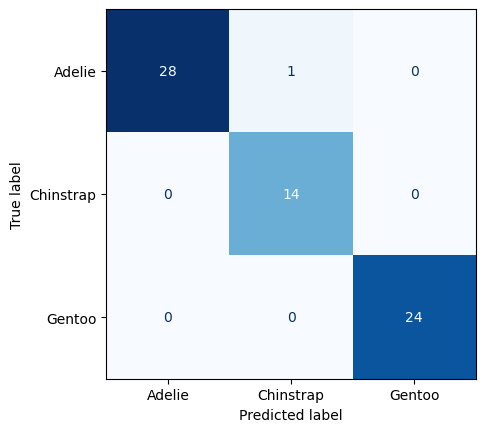

In [17]:
# how can you use this trained classifier now?
predicted_classes = clf.predict(X_test)
true_classes = y_test
matrix = confusion_matrix(true_classes, predicted_classes)
ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=clf.classes_).plot(cmap=plt.cm.Blues, colorbar=False);